In [43]:
#importing the lib
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
print(os.getcwd())

C:\Users\Nishant


In [5]:
#reading the dataset
df=pd.read_excel(r'C:\Users\Nishant\OneDrive\Documents\zepto\Zepto.xlsx')

In [6]:
df.head(10)

,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Onion,2500,16,3,2100,1000,False,1
1,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Tender Coconut,5100,15,3,4300,58,False,1
3,Coriander Leaves,2000,15,3,1700,100,False,100
4,Ladies Finger,1400,14,3,1200,250,False,250
5,Potato,3500,17,3,2900,1000,False,1
6,Lemon,7500,16,3,6300,200,False,200
7,Watermelon,5800,15,3,4900,58,False,1
8,Capsicum Green,2300,17,3,1900,250,False,250
9,Chilli Green,1900,15,3,1600,100,False,100


In [7]:
df.columns

Index(['name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='object')

basic exploration


In [8]:
print(df.shape)
print(df.info())
print(df.describe())

(93, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   name                    93 non-null     object
 1   mrp                     93 non-null     int64 
 2   discountPercent         93 non-null     int64 
 3   availableQuantity       93 non-null     int64 
 4   discountedSellingPrice  93 non-null     int64 
 5   weightInGms             93 non-null     int64 
 6   outOfStock              93 non-null     bool  
 7   quantity                93 non-null     int64 
dtypes: bool(1), int64(6), object(1)
memory usage: 5.3+ KB
None
                mrp  discountPercent  availableQuantity  \
count     93.000000        93.000000          93.000000   
mean    4701.075269        15.462366           2.956989   
std     3938.563373         2.684736           1.102507   
min     1100.000000         4.000000           0.000000   
25%     200

cateogical :- outofstock , name
numeric :- mrp , discount price availablesellingprice weightingame quantity

In [9]:
print(df.isnull().sum())

name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64


In [10]:
df['outOfStock'].value_counts()

outOfStock
False    87
True      6
Name: count, dtype: int64

eda 

In [11]:
df['name'].unique()

array(['Onion', 'Tomato Hybrid', 'Tender Coconut', 'Coriander Leaves',
       'Ladies Finger ', 'Potato', 'Lemon', 'Watermelon ',
       'Capsicum Green ', 'Chilli Green ', 'Banana Robusta',
       'Garlic Indian ', 'Cauliflower', 'Ginger', 'Spinach', 'Muskmelon',
       'Cabbage ', 'Methi', 'Broccoli', 'Sapota', 'Orange Nagpur',
       'Mint Leaves ', 'Beans French', 'Bottle Gourd ', 'Banana Elaichi ',
       'Coconut Big', 'Curry Leaves', 'Brinjal Bharta', 'Lettuce Iceberg',
       'Papaya', 'Apple Shimla', 'Bitter Gourd', 'Brinjal Small',
       'Sweet Corn', 'Spring Onion ', 'Bell Peppers Red & Yellow ',
       'Pomegranate ', 'Sweet Lime', 'Baby Potato', 'Coccinia', 'Guava',
       'Apple Washington', 'Amla', 'Beans Cluster', 'Apple Royal Gala',
       'Chilli Bhaji', 'Lettuce Green', 'Baby Corn Peeled',
       'Mixed Sprouts', 'Zucchini Green', 'Beans Broad', 'Raw Banana',
       'Colocasia ', 'Tomato Cherry ', 'Sweet Potato ', 'Pineapple Slice',
       'Orange', 'Dragon Fruit Im

In [12]:
#creating the category column by extracting the first word from the name column


# Create category mapping function
def categorize_product(name):
    name_lower = name.lower()
    
    # Vegetables
    if any(word in name_lower for word in ['onion', 'tomato', 'potato', 'carrot', 'beetroot', 'cucumber', 'capsicum', 'broccoli', 'cauliflower', 'mushroom', 'garlic', 'ginger', 'parsley', 'corn', 'bean', 'gourd', 'ladyfinger']):
        return 'Vegetables'
    
    # Leafy Greens & Herbs
    elif any(word in name_lower for word in ['coriander', 'mint', 'lettuce', 'curry', 'spinach', 'methi', 'basil', 'leaves']):
        return 'Leafy Greens'
    
    # Fruits
    elif any(word in name_lower for word in ['banana', 'apple', 'orange', 'watermelon', 'lemon', 'mango', 'papaya', 'pineapple', 'guava', 'pomegranate', 'avocado', 'coconut', 'dragon fruit', 'peach']):
        return 'Fruits'
    
    # Frozen products
    elif any(word in name_lower for word in ['frozen', 'safal', 'zama']):
        return 'Frozen'
    
    else:
        return 'Other'

# Add category column to your dataframe
df['category'] = df['name'].apply(categorize_product)

# Check the results
print(df['category'].value_counts())
print(df[['name', 'category']].head(20))

category
Vegetables      34
Fruits          27
Other           21
Leafy Greens     9
Frozen           2
Name: count, dtype: int64
                name      category
0              Onion    Vegetables
1      Tomato Hybrid    Vegetables
2     Tender Coconut        Fruits
3   Coriander Leaves  Leafy Greens
4     Ladies Finger          Other
5             Potato    Vegetables
6              Lemon        Fruits
7        Watermelon         Fruits
8    Capsicum Green     Vegetables
9      Chilli Green          Other
10    Banana Robusta        Fruits
11    Garlic Indian     Vegetables
12       Cauliflower    Vegetables
13            Ginger    Vegetables
14           Spinach  Leafy Greens
15         Muskmelon         Other
16          Cabbage          Other
17             Methi  Leafy Greens
18          Broccoli    Vegetables
19            Sapota         Other


In [13]:
df.head()

,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,category
0,Onion,2500,16,3,2100,1000,False,1,Vegetables
1,Tomato Hybrid,4200,16,3,3500,1000,False,1,Vegetables
2,Tender Coconut,5100,15,3,4300,58,False,1,Fruits
3,Coriander Leaves,2000,15,3,1700,100,False,100,Leafy Greens
4,Ladies Finger,1400,14,3,1200,250,False,250,Other


In [14]:
df['mrp_ruppees'] = df['mrp'] / 100
df['discount_selling_price_ruppees'] = df['discountedSellingPrice'] / 100

df.head(5)

,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity,category,mrp_ruppees,discount_selling_price_ruppees
0,Onion,2500,16,3,2100,1000,False,1,Vegetables,25.0,21.0
1,Tomato Hybrid,4200,16,3,3500,1000,False,1,Vegetables,42.0,35.0
2,Tender Coconut,5100,15,3,4300,58,False,1,Fruits,51.0,43.0
3,Coriander Leaves,2000,15,3,1700,100,False,100,Leafy Greens,20.0,17.0
4,Ladies Finger,1400,14,3,1200,250,False,250,Other,14.0,12.0


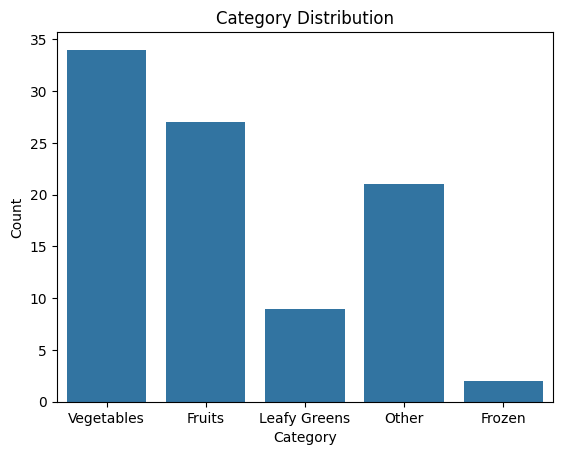

In [15]:
#performing eda uni on category column
sns.countplot(x='category', data=df)
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

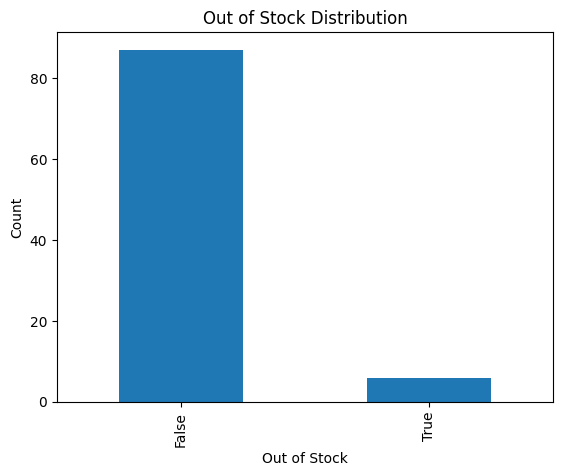

In [16]:
df['outOfStock'].value_counts().plot(kind='bar')
plt.title('Out of Stock Distribution')
plt.xlabel('Out of Stock')
plt.ylabel('Count')
plt.show()

#most of the products are in stock and very few are out of stock. So, we can say that the dataset is imbalanced.

Text(0.5, 1.0, 'Discounted Selling Price Distribution by Category')

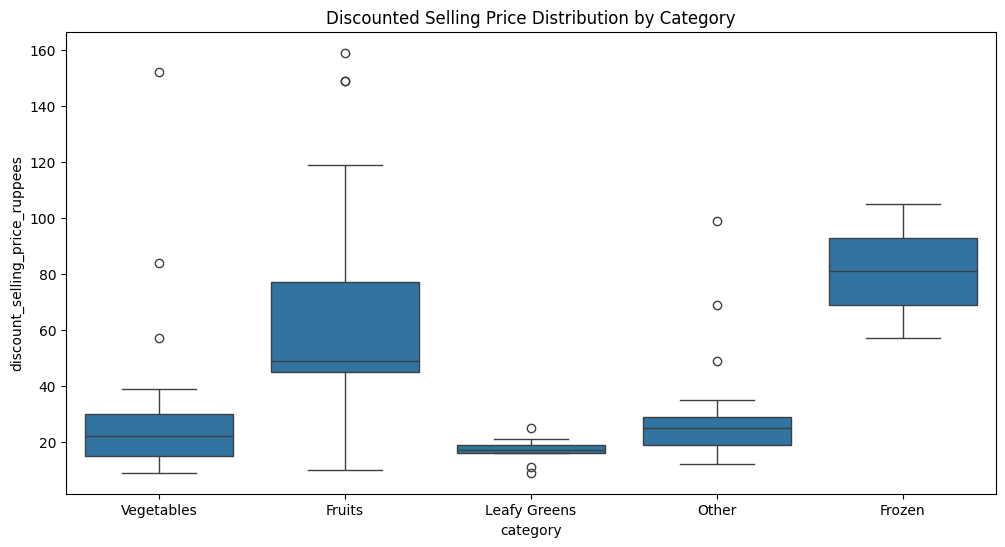

In [17]:
#eda discountedSellingPrice column and category column
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='discount_selling_price_ruppees', data=df)
plt.title('Discounted Selling Price Distribution by Category')

#outliers are present in the dataset. So, we can say that the dataset is not clean.

In [18]:
df.columns

Index(['name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity',
       'category', 'mrp_ruppees', 'discount_selling_price_ruppees'],
      dtype='object')

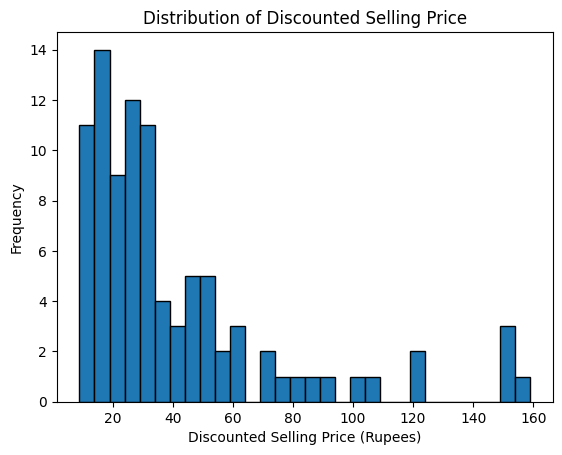

In [19]:
plt.hist(df['discount_selling_price_ruppees'], bins=30, edgecolor='k')
plt.title('Distribution of Discounted Selling Price')
plt.xlabel('Discounted Selling Price (Rupees)')
plt.ylabel('Frequency')
plt.show()



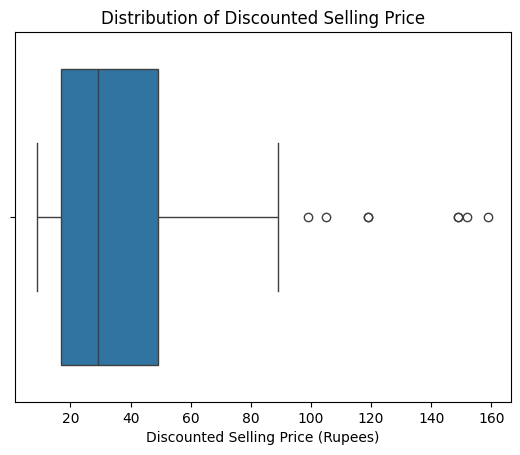

In [20]:
sns.boxplot(x='discount_selling_price_ruppees', data=df)
plt.title('Distribution of Discounted Selling Price')
plt.xlabel('Discounted Selling Price (Rupees)')
plt.show()
#having the outliers in the dataset, we can say that the dataset is not clean. So, we need to clean the dataset by removing the outliers.

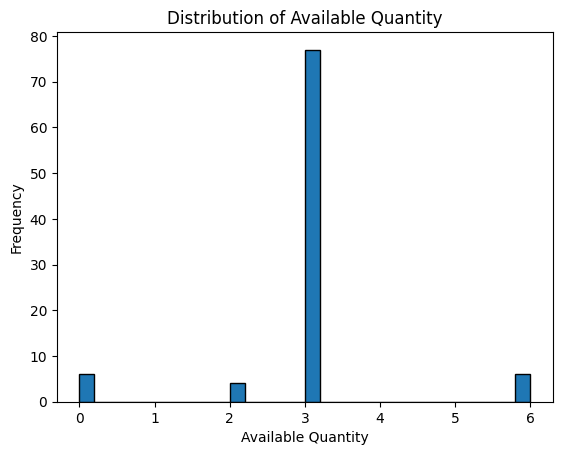

<Axes: ylabel='availableQuantity'>

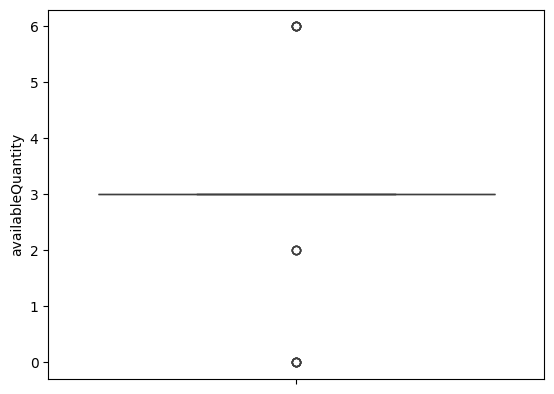

In [24]:
plt.hist(df['availableQuantity'], bins=30, edgecolor='k')
plt.title('Distribution of Available Quantity')
plt.xlabel('Available Quantity')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(df['availableQuantity'])



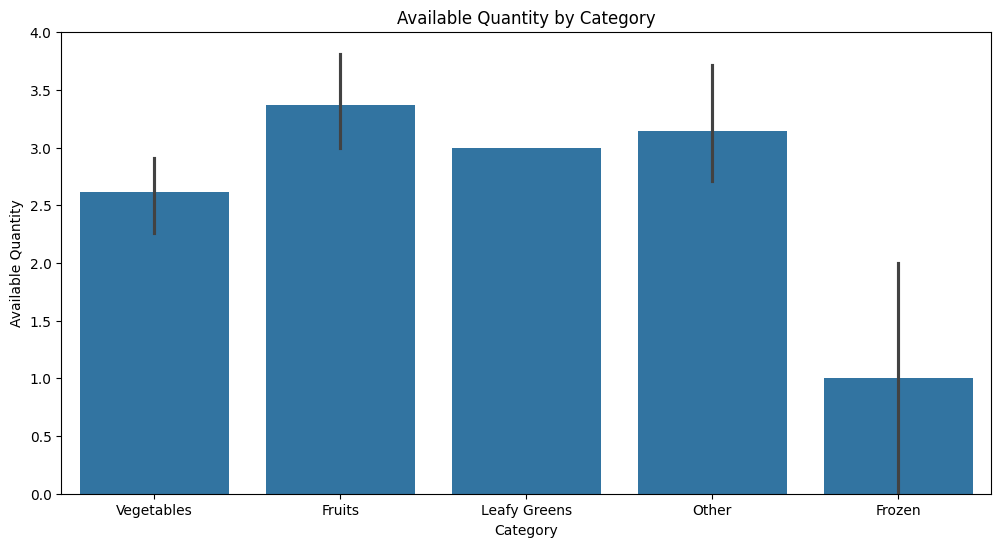

In [22]:
#categorical analysis of availableQuantity column
plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='availableQuantity', data=df)
plt.xlabel('Category')
plt.ylabel('Available Quantity')
plt.title('Available Quantity by Category')
plt.show()

<Axes: xlabel='category', ylabel='discount_selling_price_ruppees'>

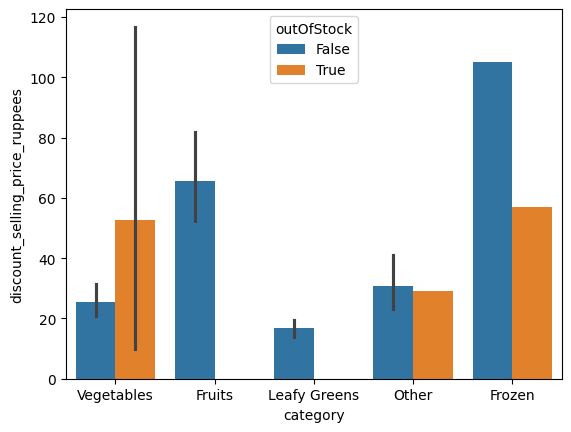

In [31]:
sns.barplot(x='category',y='discount_selling_price_ruppees',hue='outOfStock',data=df)

<Axes: xlabel='category', ylabel='weightInGms'>

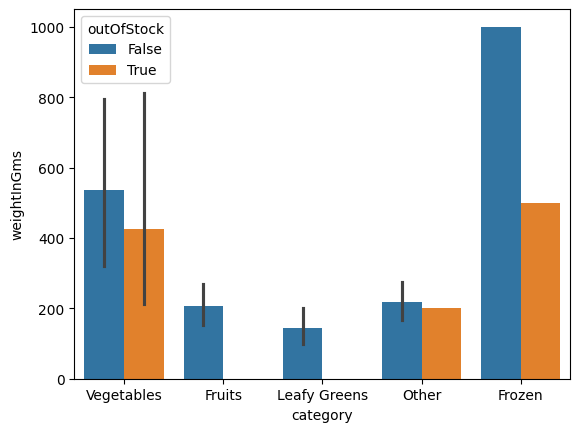

In [36]:
#creating the plot distplot cateogry and weightin grams
sns.barplot(data=df,y='weightInGms',x='category',hue='outOfStock')


correlation analysis


<Axes: >

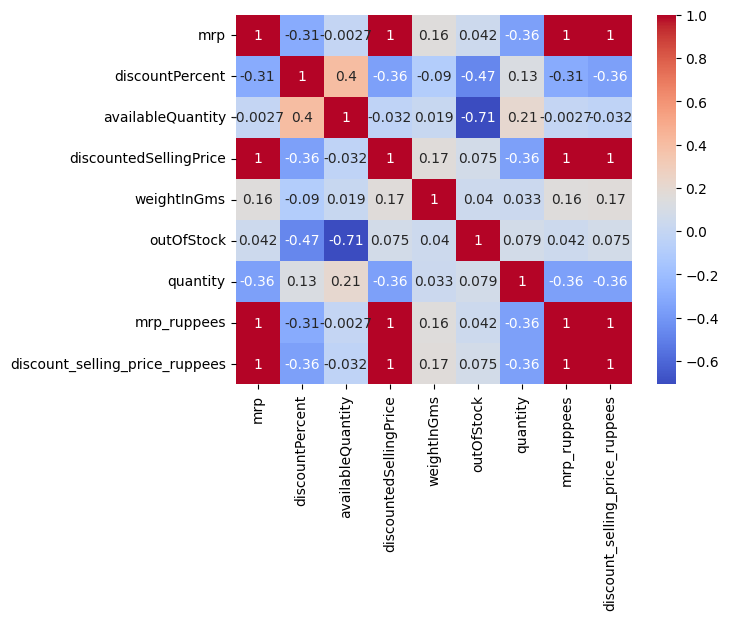

In [38]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

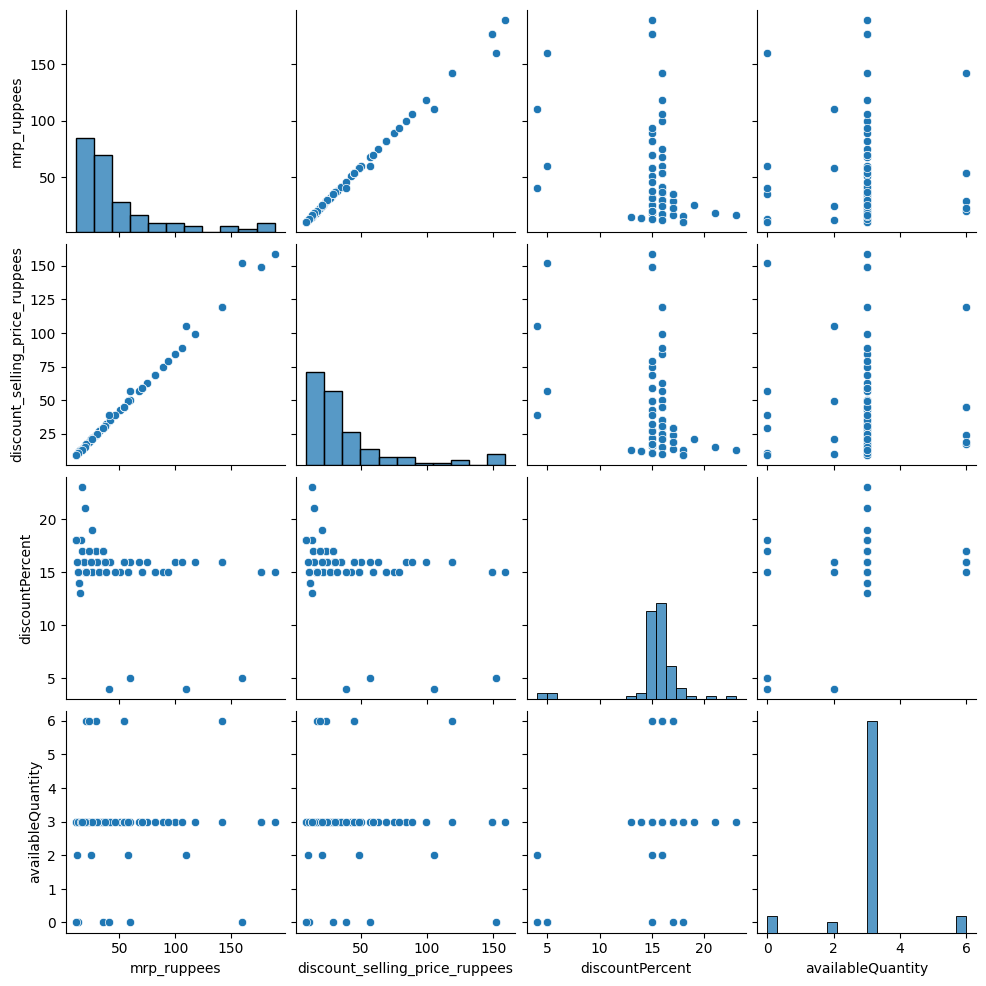

In [41]:
sns.pairplot(df[
    ['mrp_ruppees','discount_selling_price_ruppees','discountPercent','availableQuantity']
])
plt.show()

In [45]:
clean_df=df.copy()
clean_df.to_excel("./Zepto_cleaned.xlsx",index=False)

In [46]:
print(os.getcwd())

C:\Users\Nishant
